# Figure 2: SST Context Maps with Storm Tracks

**2×2 panel** (one per storm) showing:
- OISST v2.1 SST field at peak intensity date  
- Storm track colour-coded by `USA_WIND`  
- Impact reference point (★)  

**Answers Q5**: How does the SST environment differ between WNP and Atlantic?  
**Prerequisites**: `data/oisst/{storm}_sst.nc` and `data/ibtracs/{storm}_track.csv`.

## 1: Setup

In [1]:
import os, sys, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from utils import IBTRACS_DIR, OISST_DIR, FIG_DIR, STORM_ORDER, STORMS, ensure_dirs

ensure_dirs()
OUTPATH   = os.path.join(FIG_DIR, 'sst_maps.png')
SST_CMAP  = 'RdYlBu_r'
VMIN_SST, VMAX_SST   = 20.0, 32.0
VMIN_WIND, VMAX_WIND = 40, 165

## 2: Helper: load SST DataArray

In [2]:
def load_sst(key):
    nc = os.path.join(OISST_DIR, f'{key}_sst.nc')
    if not os.path.exists(nc):
        print(f'[{key}] SST file not found: {nc}')
        return None
    try:
        ds  = xr.open_dataset(nc)
        sst = ds['sst'].squeeze()
        return sst
    except Exception as exc:
        print(f'[{key}] Cannot load SST: {exc}')
        return None


def plot_panel(ax, key, track_df, sst):
    meta = STORMS[key]
    ax.set_extent(
        [meta['oisst_bbox'][1], meta['oisst_bbox'][3],
         meta['oisst_bbox'][0], meta['oisst_bbox'][2]],
        crs=ccrs.PlateCarree()
    )
    ax.add_feature(cfeature.LAND,      facecolor='0.80', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6,    zorder=3)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3, linestyle=':', zorder=3)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='0.6',
                      x_inline=False, y_inline=False)
    gl.top_labels = gl.right_labels = False
    gl.xlabel_style = gl.ylabel_style = {'size': 7}

    if sst is not None:
        try:
            sst.plot(ax=ax, transform=ccrs.PlateCarree(),
                     cmap=SST_CMAP, vmin=VMIN_SST, vmax=VMAX_SST,
                     add_colorbar=False, zorder=1)
        except Exception as exc:
            print(f'[{key}] SST plot error: {exc}')
    else:
        ax.set_facecolor('#aec6cf')
        ax.text(0.5, 0.5, 'SST not available', transform=ax.transAxes,
                ha='center', va='center', color='white', fontsize=9)

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        sc = ax.scatter(
            track_df['LON'], track_df['LAT'],
            c=track_df['USA_WIND'], cmap='hot_r',
            vmin=VMIN_WIND, vmax=VMAX_WIND,
            s=12, transform=ccrs.PlateCarree(), zorder=5, linewidths=0
        )
        ax.plot(track_df['LON'], track_df['LAT'],
                color='k', linewidth=0.8, transform=ccrs.PlateCarree(), zorder=4)

    ax.scatter(meta['impact_lon'], meta['impact_lat'],
               marker='*', s=150, color='white',
               edgecolors='k', linewidths=0.7,
               transform=ccrs.PlateCarree(), zorder=6)

    ax.set_title(
        f"{meta['name']} ({meta['year']}): {meta['basin']}\n"
        f"Impact: {meta['impact_label']}",
        fontsize=9, fontweight='bold'
    )
    return sc


print('Helpers defined.')

Helpers defined.


## 3: Assemble and save

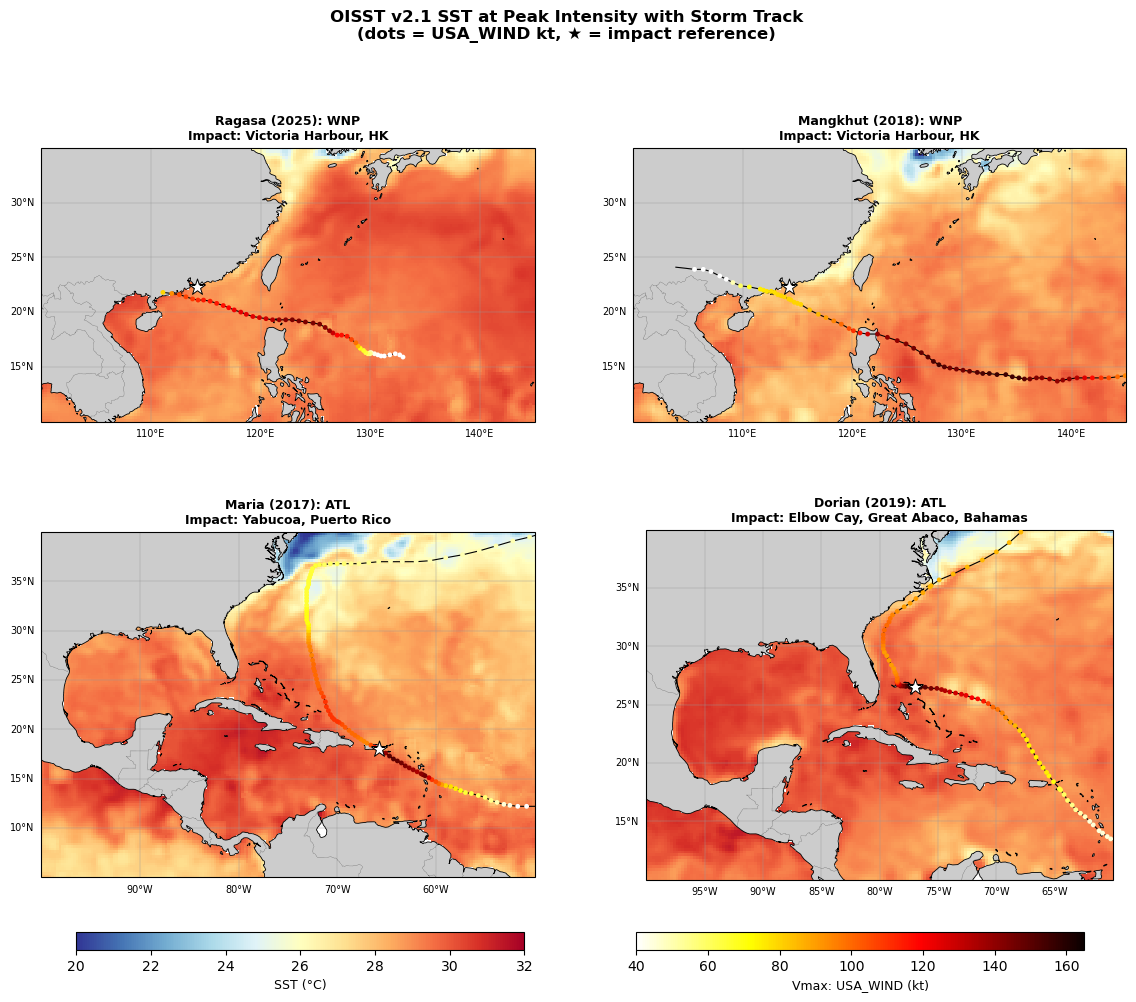

Saved → /home/sharperace/geog_1.02_final_proj/figures/sst_maps.png


In [3]:
fig, axes = plt.subplots(
    2, 2, figsize=(14, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

for i, key in enumerate(STORM_ORDER):
    ax = axes.flatten()[i]
    track_csv = os.path.join(IBTRACS_DIR, f'{key}_track.csv')
    if not os.path.exists(track_csv):
        ax.set_visible(False)
        continue
    track_df = pd.read_csv(track_csv, parse_dates=['ISO_TIME'])
    sst = load_sst(key)
    plot_panel(ax, key, track_df, sst)

# Shared SST colourbar
cax_sst = fig.add_axes([0.15, 0.04, 0.32, 0.018])
cb_sst  = fig.colorbar(
    plt.cm.ScalarMappable(cmap=SST_CMAP,
                          norm=mcolors.Normalize(VMIN_SST, VMAX_SST)),
    cax=cax_sst, orientation='horizontal'
)
cb_sst.set_label('SST (°C)', fontsize=9)

# Shared wind colourbar
cax_wind = fig.add_axes([0.55, 0.04, 0.32, 0.018])
cb_wind  = fig.colorbar(
    plt.cm.ScalarMappable(cmap='hot_r',
                          norm=mcolors.Normalize(VMIN_WIND, VMAX_WIND)),
    cax=cax_wind, orientation='horizontal'
)
cb_wind.set_label('Vmax: USA_WIND (kt)', fontsize=9)

fig.suptitle(
    'OISST v2.1 SST at Peak Intensity with Storm Track\n'
    '(dots = USA_WIND kt, ★ = impact reference)',
    fontsize=12, fontweight='bold'
)
plt.savefig(OUTPATH, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {OUTPATH}')